In [ ]:
# ffmpeg -i input_video.mp4 -vcodec libx264 -crf 25 \
#        -x264opts "bframes=0:keyint=30" encoded_output_video.mp4

In [1]:
!pip install requests

In [2]:
import requests

spec = requests.get("http://localhost:8100/openapi.json", timeout=10).json()
for p in sorted(spec["paths"]):
    print(p, list(spec["paths"][p].keys()))

/alerts ['get', 'post']
/alerts/recent ['get']
/alerts/{alert_id} ['delete']
/chat/completions ['post']
/files ['post', 'get']
/files/{file_id} ['delete', 'get']
/files/{file_id}/content ['get']
/generate_vlm_captions ['post']
/health/live ['get']
/health/ready ['get']
/live-stream ['get', 'post']
/live-stream/{stream_id} ['delete']
/metrics ['get']
/models ['get']
/recommended_config ['post']
/reviewAlert ['post']
/summarize ['post']


In [3]:
import os
import re
import json
from pathlib import Path

import requests

RTVLM = os.environ.get("VSS_RTVLM_URL", "http://127.0.0.1:8100").rstrip("/")
LLM = os.environ.get("VSS_LLM_URL", "http://127.0.0.1:38011").rstrip("/")

# Stage 1 (VLM, sees frames): keep it GENERAL so captions can answer questions
# about ANY move, not a fixed list.
CAPTION_PROMPT = (
    "Number each person from left to right. Write a dense caption describing "
    "every action, pose, and dance move each person performs, always referring "
    "to a person by their number."
)

_THINK = re.compile(r"<think>.*?</think>", re.DOTALL | re.IGNORECASE)


def _first_model(url, path):
    return requests.get(f"{url}{path}", timeout=15).json()["data"][0]["id"]


def caption_video(path, chunk_duration=1):
    """Upload a clip and densely caption it. Returns ordered [(start, end, text)].

    chunk_duration is the game's TEMPORAL RESOLUTION: each chunk yields one
    timestamped caption, so keep it small (1-2s) or "who moved first" collapses
    into a single timeless caption. num_frames_per_chunk stays <=5 (cosmos3
    caps a prompt at 5 images). Runs once; ask many questions against the result.
    """
    path = Path(path)
    with path.open("rb") as f:
        file_id = requests.post(
            f"{RTVLM}/files",
            files={"file": (path.name, f, "video/mp4")},
            data={"purpose": "vision", "media_type": "video"},
            timeout=(15, 300),
        ).json()["id"]
    try:
        chunks = requests.post(
            f"{RTVLM}/generate_vlm_captions",
            json={
                "id": file_id,
                "model": _first_model(RTVLM, "/models"),
                "prompt": CAPTION_PROMPT,
                "chunk_duration": chunk_duration,
                "chunk_overlap_duration": 1,
                "num_frames_per_chunk": 5,
            },
            timeout=(15, 900),
        ).json()["chunk_responses"]
    finally:
        requests.delete(f"{RTVLM}/files/{file_id}", timeout=30)

    caps = [
        (c["start_time"], c["end_time"], _THINK.sub("", c["content"]).strip())
        for c in chunks
    ]
    return sorted(caps, key=lambda c: c[0])


def first_performer(captions, moves):
    """First person to perform a move, or to complete a sequence in order.

    `moves` is a move string, or a list of moves to be done in order. One call
    to the text NIM over the whole timestamped timeline (NOT VSS RAG chat, whose
    retrieval is empty here). Returns:
        {"winner": int,        # person number, 0 == nobody did it
         "timestamp": float,   # seconds when they finish (null if nobody)
         "num_people": int}
    """
    if isinstance(moves, str):
        task = f"perform the move: '{moves}'"
    else:
        task = "complete ALL of these moves, in this order: " + \
               "; then ".join(moves)

    timeline = "\n".join(f"[{s} - {e}] {t}" for s, e, t in captions if t)
    prompt = (
        "You are given timestamped video captions. People are numbered "
        "left-to-right and keep the same number across time.\n\n"
        f"TIMELINE:\n{timeline}\n\n"
        f"Find the FIRST person (earliest timestamp) to {task}.\n"
        "Answer with ONLY JSON, no prose:\n"
        '{"winner": <person number, or 0 if nobody>, '
        '"timestamp": <seconds when they finish, or null>, '
        '"num_people": <total people visible>}'
    )
    r = requests.post(
        f"{LLM}/v1/chat/completions",
        json={
            "model": _first_model(LLM, "/v1/models"),
            "messages": [{"role": "user", "content": prompt}],
            "temperature": 0.0,
            "max_tokens": 200,
        },
        timeout=(15, 300),
    ).json()
    text = _THINK.sub("", r["choices"][0]["message"]["content"])
    return json.loads(re.search(r"\{.*\}", text, re.DOTALL).group())

In [4]:
# One-time: fetch the ONNX models for OpenCV's DNN module (cached under ./models).
#   * YOLOX      - person detection (winner_snapshot boxes)
#   * YOLOv8-pose - 17-keypoint pose, used to time "arms crossed" deterministically
# ~50 MB total. Re-runs are no-ops once the files exist.
import os
import urllib.request

_MODELS_DIR = "models"
os.makedirs(_MODELS_DIR, exist_ok=True)

_MODELS = {
    "yolox.onnx": ("https://media.githubusercontent.com/media/opencv/opencv_zoo/"
                   "main/models/object_detection_yolox/"
                   "object_detection_yolox_2022nov.onnx"),
    "yolov8n-pose.onnx": ("https://huggingface.co/Xenova/yolov8n-pose/"
                          "resolve/main/onnx/model.onnx"),
}

for name, url in _MODELS.items():
    path = os.path.join(_MODELS_DIR, name)
    if not os.path.exists(path) or os.path.getsize(path) < 1_000_000:
        print(f"Downloading {name} ...")
        urllib.request.urlretrieve(url, path)
    print(f"ready: {path} ({os.path.getsize(path) // (1024*1024)} MB)")

ready: models/yolox.onnx (34 MB)
ready: models/yolov8n-pose.onnx (12 MB)


In [5]:
import cv2
import numpy as np

# Person detector: YOLOX (COCO) run through OpenCV's DNN module. This gives
# REAL bounding boxes, unlike asking the VLM for coordinates (which drifted
# onto walls/doors). Model files live in ./models (see the download cell).
YOLOX_ONNX = os.environ.get("YOLOX_ONNX", "models/yolox.onnx")
_YOLOX_INP = 640
_YOLOX_STRIDES = (8, 16, 32)
_yolox_net = None


def _yolox():
    global _yolox_net
    if _yolox_net is None:
        _yolox_net = cv2.dnn.readNetFromONNX(YOLOX_ONNX)
    return _yolox_net


def _yolox_grids():
    grids, strides = [], []
    for s in _YOLOX_STRIDES:
        g = _YOLOX_INP // s
        xv, yv = np.meshgrid(np.arange(g), np.arange(g))
        grid = np.stack((xv, yv), 2).reshape(-1, 2)
        grids.append(grid)
        strides.append(np.full((grid.shape[0], 1), s))
    return np.concatenate(grids, 0), np.concatenate(strides, 0)


_GRID, _EXP = _yolox_grids()


def detect_people(frame, conf_th=0.35, nms_th=0.45):
    """Detect people in a BGR frame. Returns [(x0, y0, x1, y1), ...] in pixels,
    sorted left-to-right so index N-1 is 'person N' (same numbering the
    captions use)."""
    h, w = frame.shape[:2]
    r = min(_YOLOX_INP / h, _YOLOX_INP / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    canvas = np.full((_YOLOX_INP, _YOLOX_INP, 3), 114, np.uint8)
    canvas[:nh, :nw] = cv2.resize(frame, (nw, nh))

    net = _yolox()
    net.setInput(cv2.dnn.blobFromImage(canvas, 1.0, (_YOLOX_INP, _YOLOX_INP),
                                       swapRB=False, crop=False))
    out = net.forward()[0]                          # [8400, 85]
    xy = (out[:, :2] + _GRID) * _EXP
    wh = np.exp(out[:, 2:4]) * _EXP
    scores = out[:, 4:5] * out[:, 5:]               # obj_conf * class_conf
    cls = np.argmax(scores, 1)
    conf = scores[np.arange(len(scores)), cls]
    keep = (cls == 0) & (conf > conf_th)            # class 0 == person (COCO)
    xy, wh, conf = xy[keep], wh[keep], conf[keep]
    boxes = np.concatenate([xy - wh / 2, wh], 1) / r  # xywh in original pixels

    idx = cv2.dnn.NMSBoxes(boxes.tolist(), conf.tolist(), conf_th, nms_th)
    kept = [boxes[i] for i in np.array(idx).flatten()] if len(idx) else []
    kept.sort(key=lambda b: b[0])                   # left-to-right
    return [(int(x), int(y), int(x + bw), int(y + bh)) for x, y, bw, bh in kept]


def winner_snapshot(video_path, timestamp, winner_number, num_people,
                    out_path="winner.jpg"):
    """Still frame at the winning moment with the winner boxed.

    Boxes the winner with a real person-detection box (YOLOX) for that frame,
    matching person N to the Nth detection from the left. If the detector
    doesn't find at least winner_number people, falls back to the naive
    equal-column split so the cell still produces an image.
    """
    cap = cv2.VideoCapture(str(video_path))
    if timestamp is not None:
        cap.set(cv2.CAP_PROP_POS_MSEC, float(timestamp) * 1000.0)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read a frame from {video_path}")

    h, w = frame.shape[:2]
    people = detect_people(frame)
    if len(people) >= winner_number:
        x0, y0, x1, y1 = people[winner_number - 1]
    else:
        col = w / num_people
        x0, y0, x1, y1 = (int((winner_number - 1) * col) + 6, 6,
                          int(winner_number * col) - 6, h - 6)

    x0, x1 = max(0, x0), min(w, x1)
    y0, y1 = max(0, y0), min(h, y1)
    color = (0, 215, 255)  # amber, BGR
    label = f"WINNER: Person {winner_number} @ {timestamp}s"
    cv2.rectangle(frame, (x0, y0), (x1, y1), color, 4)
    label_y = y0 - 12 if y0 - 12 > 24 else min(h - 8, y1 + 32)
    cv2.putText(frame, label, (x0 + 4, label_y), cv2.FONT_HERSHEY_SIMPLEX,
                1.0, color, 2, cv2.LINE_AA)
    cv2.imwrite(str(out_path), frame)
    return out_path

In [6]:
# Deterministic "who crossed their arms first".
#
# The VLM captions can't resolve sub-second ordering of a near-simultaneous
# move -- they list people in numeric order, so the reasoner just picks person
# 1. Instead we run YOLOv8-pose per frame and decide "arms crossed" from
# geometry, giving an exact per-person onset time. No LLM in the timing loop.
YOLO_POSE_ONNX = os.environ.get("YOLO_POSE_ONNX", "models/yolov8n-pose.onnx")
_POSE_INP = 640
_pose_net = None
# COCO keypoints: 5 L-shoulder  6 R-shoulder  9 L-wrist  10 R-wrist  11 L-hip  12 R-hip


def _pose():
    global _pose_net
    if _pose_net is None:
        _pose_net = cv2.dnn.readNetFromONNX(YOLO_POSE_ONNX)
    return _pose_net


def pose_people(frame, conf_th=0.5, nms_th=0.45):
    """People with 17 COCO keypoints. Returns [(center_x, kp[17,3]), ...] sorted
    left-to-right; each kp row is (x_px, y_px, visibility)."""
    h, w = frame.shape[:2]
    r = min(_POSE_INP / h, _POSE_INP / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    canvas = np.full((_POSE_INP, _POSE_INP, 3), 114, np.uint8)
    canvas[:nh, :nw] = cv2.resize(frame, (nw, nh))
    net = _pose()
    net.setInput(cv2.dnn.blobFromImage(canvas, 1 / 255.0, (_POSE_INP, _POSE_INP),
                                       swapRB=True, crop=False))
    out = net.forward()[0].T                        # [8400, 56]
    conf = out[:, 4]
    keep = conf > conf_th
    out, conf = out[keep], conf[keep]
    if len(out) == 0:
        return []
    boxes = out[:, :4].copy()
    boxes[:, 0] -= boxes[:, 2] / 2
    boxes[:, 1] -= boxes[:, 3] / 2
    idx = cv2.dnn.NMSBoxes((boxes / r).tolist(), conf.tolist(), conf_th, nms_th)
    people = []
    for i in np.array(idx).flatten():
        kp = out[i, 5:].reshape(17, 3).copy()
        kp[:, 0] /= r
        kp[:, 1] /= r
        people.append((float(out[i, 0] / r), kp))
    people.sort(key=lambda p: p[0])
    return people


def arms_crossed(kp, ratio_th=0.55):
    """True when the wrists are pulled together over the torso (arms crossed).

    Arms at sides: horizontal wrist gap ~= shoulder width (ratio ~1). Crossed:
    wrists meet/swap over the chest (ratio ~0 or negative). We also require the
    wrists to be at/below shoulder height so a raised 'hands up' pose (small gap
    but overhead) doesn't count.
    """
    Lsh, Rsh, Lwr, Rwr, Lhip, Rhip = (kp[5], kp[6], kp[9], kp[10], kp[11], kp[12])
    if min(Lwr[2], Rwr[2], Lsh[2], Rsh[2]) < 0.4:
        return False
    shoulder_w = abs(Lsh[0] - Rsh[0])
    if shoulder_w < 5:
        return False
    gap = (Lwr[0] - Rwr[0]) / shoulder_w
    sh_y = (Lsh[1] + Rsh[1]) / 2
    torso = abs((Lhip[1] + Rhip[1]) / 2 - sh_y) + 1e-3
    at_chest = (Lwr[1] > sh_y - 0.1 * torso) and (Rwr[1] > sh_y - 0.1 * torso)
    return gap < ratio_th and at_chest


def first_to_cross_arms(video_path, dt=0.1, t_start=0.0, t_end=None):
    """First person to cross their arms, timed from pose (not from the VLM).

    Returns {"winner","timestamp","num_people"} (winner 0 / timestamp None if
    nobody). People are matched to fixed left-to-right columns so 'person N'
    lines up with the caption numbering used elsewhere.
    """
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    n_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0
    duration = (n_frames / fps) if n_frames else None
    if t_end is None:
        t_end = duration if duration else 1e9

    samples = []                                    # [(t, [(cx, kp), ...]), ...]
    t = t_start
    while t <= t_end:
        cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000.0)
        ok, frame = cap.read()
        if not ok:
            break
        samples.append((round(t, 3), pose_people(frame)))
        t += dt
    cap.release()

    ref = max((p for _, p in samples), key=len, default=[])
    if not ref:
        return {"winner": 0, "timestamp": None, "num_people": 0}
    columns = [cx for cx, _ in ref]                 # left-to-right reference x
    num = len(columns)

    onset = {}
    for ts, people in samples:
        for cx, kp in people:
            person = 1 + min(range(num), key=lambda j: abs(cx - columns[j]))
            if arms_crossed(kp) and person not in onset:
                onset[person] = ts
    if not onset:
        return {"winner": 0, "timestamp": None, "num_people": num}
    winner = min(onset, key=onset.get)
    return {"winner": winner, "timestamp": onset[winner], "num_people": num}

{'winner': 3, 'timestamp': 0.8, 'num_people': 4}


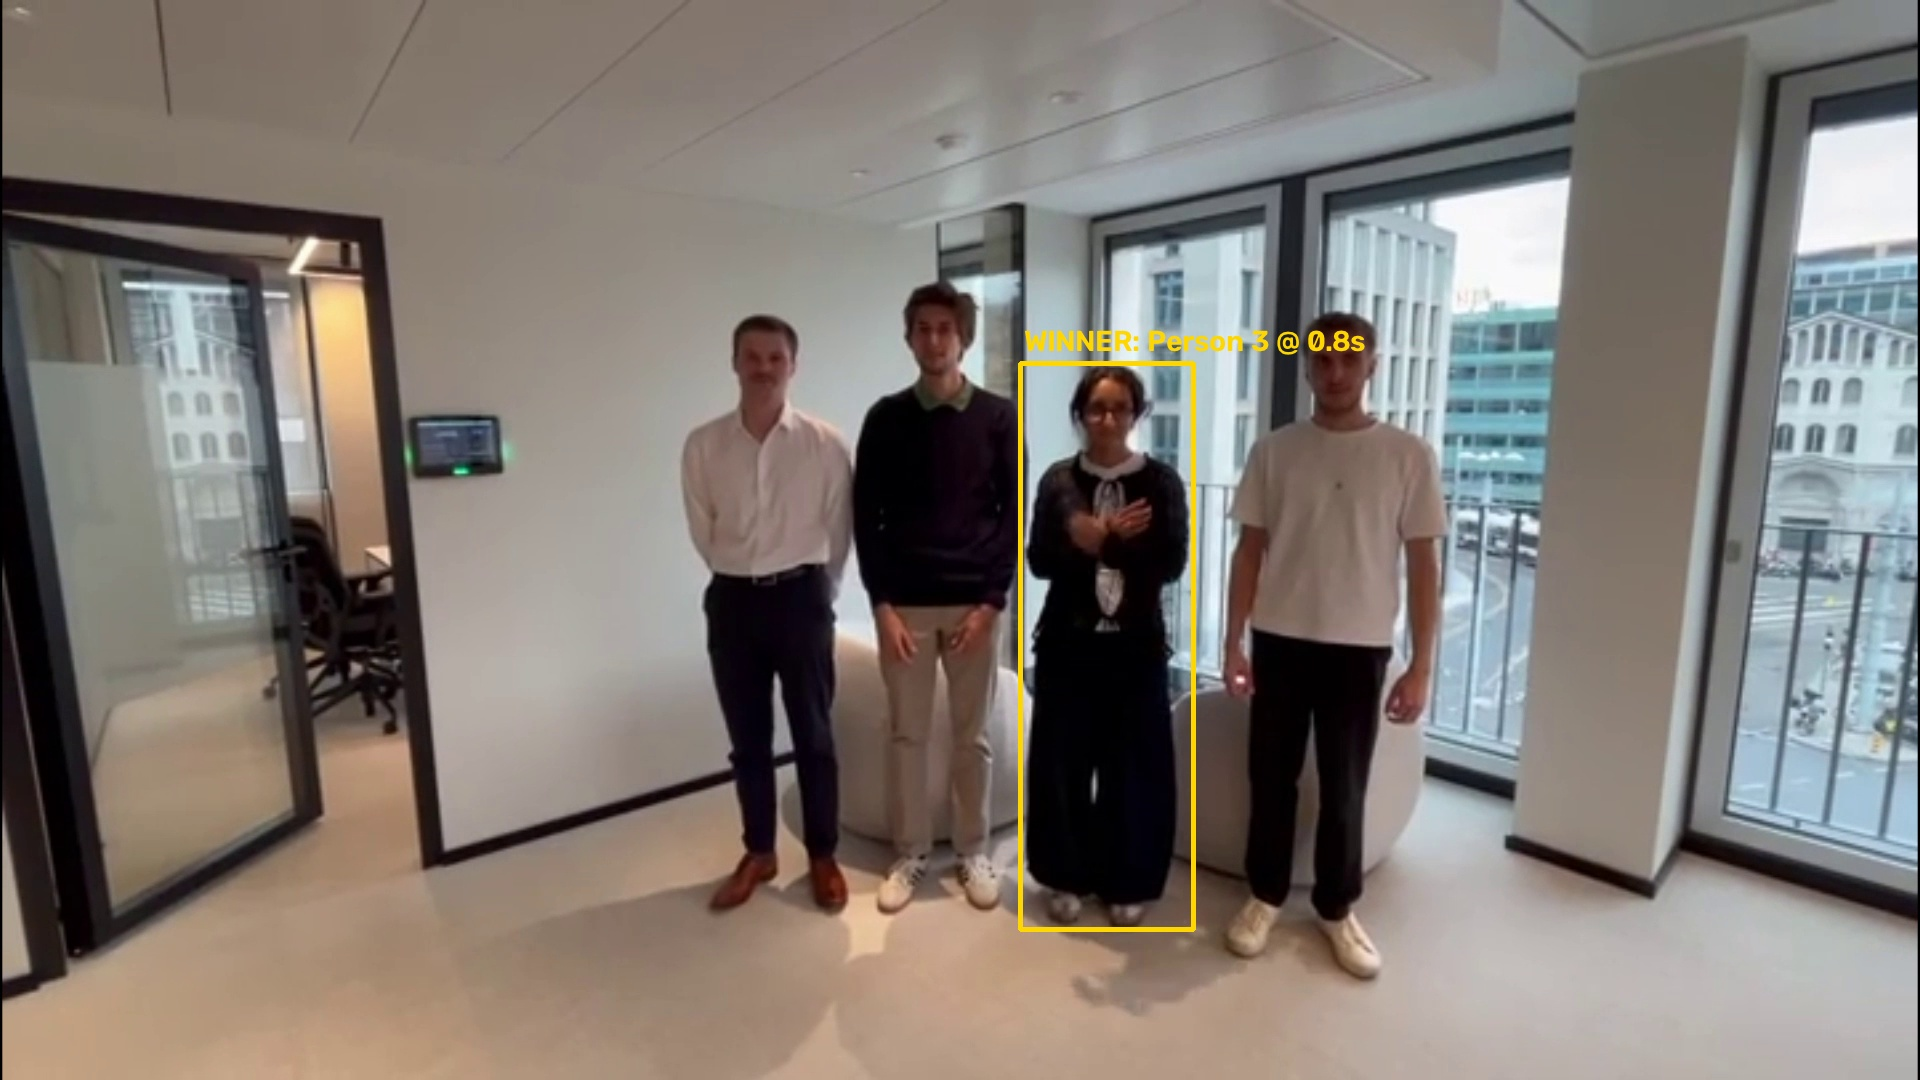

In [24]:
# "Who crossed their arms first?" -- pose-timed, so near-simultaneous moves are
# ordered correctly (the VLM path can't resolve sub-second differences).
from IPython.display import Image

VIDEO = "../video/stagiaires.mp4"

res = first_to_cross_arms(VIDEO)
print(res)

if not res["winner"]:
    print("Nobody crosses their arms.")
else:
    photo = winner_snapshot(VIDEO, res["timestamp"], res["winner"],
                            res["num_people"])
    display(Image(str(photo)))

In [13]:
# Caption once, then ask as many questions as you like against `captions`.
captions = caption_video("../video/stagiaires.mp4", chunk_duration=2)

print("=== TIMELINE ===")
for s, e, t in captions:
    print(f"[{s} - {e}] {t}")

print("\nFirst to cross arms:", first_performer(captions, "cross their arms"))
print("First to finish the sequence:", first_performer(
    captions, ["cross arms", "turn around", "touch your head"]))

=== TIMELINE ===
[0.0 - 2.0] From left to right: Person 1 is wearing a white shirt, dark pants, and brown shoes. Person 2 is wearing a dark sweater, light pants, and white sneakers. Person 3 is wearing a black outfit with a white shirt underneath. Person 4 is wearing a white t-shirt, dark pants, and white sneakers. 

At <0.0>: Person 1, 2, 3, and 4 are standing in a line, facing forward.

At <0.4>: Person 3 raises their hands and claps.

At <0.8>: Person 1, 2, 3, and 4 raise their hands and clap.

At <1.2>: Person 1, 2, 3, and 4 lower their hands.

At <1.6>: Person 1, 2, 3, and 4 raise their hands and cross their arms.
[1.0 - 3.0] From left to right: Person 1 is wearing a white shirt and dark pants, standing with his arms initially at his sides, then crossing them over his chest. Person 2 is wearing a dark sweater and light pants, standing with his arms initially at his sides, then crossing them over his chest. Person 3 is wearing a black outfit with a white shirt underneath, standing 

In [7]:
# Find the winner and show a photo of them at the winning moment.
from IPython.display import Image

VIDEO = "../video/stagiaires.mp4"
MOVES = "cross arms"  # or a list, e.g. ["touch boot", "clap hands"]
# MOVES = ["cross arms", "turn around", "touch head"]  # or a list, e.g. ["touch boot", "clap hands"]

# chunk_duration is the temporal resolution. Keep it 1s: brief actions near the
# end of the clip (e.g. the head-touch here at ~5s) get averaged away at 2s.
captions = caption_video(VIDEO, chunk_duration=2)
res = first_performer(captions, MOVES)
print(res)

if not res["winner"]:
    print("Nobody performs the move (try smaller chunk_duration or a clearer move).")
else:
    photo = winner_snapshot(VIDEO, res["timestamp"], res["winner"],
                            res["num_people"])
    display(Image(str(photo)))

KeyboardInterrupt: 